<a href="https://colab.research.google.com/github/Kaneriah43/Flyrank_Ml_Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kaneriah43/Flyrank_Ml_Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
import os
import json
import numpy as np
import pandas as pd
import getpass
import duckdb
import matplotlib.pyplot as plt
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [4]:
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): ")

Paste your Hugging Face READ token (hf_...): ··········


In [5]:
con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')")

In [6]:
REL = "hf://datasets/FlyRank/internship-warehouse"

In [7]:
TABLES = {
    "dim_clients":    f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content":    f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily":     f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

In [8]:
df = con.execute(f"""
    WITH base AS (
        SELECT
            d.content_hash_id,
            d.client_hash_id,
            d.month,
            d.report_date,
            d.gsc_impressions,
            d.gsc_clicks,
            d.gsc_avg_position,
            MAX(d.report_date) OVER (
                PARTITION BY d.content_hash_id, d.client_hash_id
            ) AS max_date
        FROM {TABLES['fact_daily']} d
        WHERE d.month = '2026-03'
          AND d.gsc_data_available = TRUE
    )
    SELECT
        b.content_hash_id,
        b.client_hash_id,
        b.month,
        SUM(b.gsc_impressions)                                       AS impressions_90d,
        SUM(b.gsc_clicks)                                            AS clicks_90d,
        AVG(b.gsc_avg_position)                                      AS avg_position,
        SUM(b.gsc_clicks) / NULLIF(SUM(b.gsc_impressions), 0)       AS ctr,
        SUM(CASE WHEN b.report_date >= (b.max_date - INTERVAL 30 DAYS)
                 THEN b.gsc_impressions ELSE 0 END)                  AS impressions_last30,
        SUM(CASE WHEN b.report_date < (b.max_date - INTERVAL 30 DAYS)
                 THEN b.gsc_impressions ELSE 0 END)                  AS impressions_prev30,
        c.content_type,
        c.word_count,
        c.last_optimized_date,
        DATEDIFF('day', c.last_optimized_date, MAX(b.report_date))  AS days_since_last_update,
        DATEDIFF('day', c.content_created_date, MAX(b.report_date)) AS content_age_days
    FROM base b
    JOIN {TABLES['dim_content']} c
        ON b.content_hash_id = c.content_hash_id
    GROUP BY
        b.content_hash_id, b.client_hash_id, b.month,
        c.content_type, c.word_count,
        c.last_optimized_date, c.content_created_date
""").df()

df["days_since_last_update"] = df["days_since_last_update"].abs()
df["content_age_days"]       = df["content_age_days"].abs()

print(f"Rows loaded: {len(df):,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows loaded: 176,738


In [9]:
df["ctr_opportunity"] = np.where(
    df["avg_position"] <= 10,
    df["ctr"] < df.groupby(
        pd.cut(df["avg_position"], bins=[0, 3, 5, 10, 20, 100])
    )["ctr"].transform("median"),
    False
)
df["is_declining_label"] = (
    (df["impressions_90d"] >= df["impressions_90d"].median()) &
    (df["ctr_opportunity"] == True)
).astype(int)

/tmp/ipykernel_784/614048139.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["ctr"] < df.groupby(


In [10]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk  = np.asarray(labels)[order[:k]]
    return topk.mean()

In [11]:
features = ["impressions_90d", "clicks_90d", "avg_position",
            "ctr", "days_since_last_update", "content_age_days", "word_count"]

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0).values
y = df["is_declining_label"].values

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                             max_depth=5, random_state=42)
rf.fit(X_train, y_train)

df["priority_score"] = rf.predict_proba(X)[:, 1]

print(f"Rows loaded:      {len(df):,}")
print(f"Positive labels:  {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"P@50 on test set: {precision_at_k(rf.predict_proba(X_test)[:,1], y_test, 50):.3f}")
print(f"priority_score added — min: {df['priority_score'].min():.3f}, max: {df['priority_score'].max():.3f}")

Rows loaded:      176,738
Positive labels:  3,416 (1.9%)
P@50 on test set: 1.000
priority_score added — min: 0.000, max: 0.970


## 1. Question

*The research question and the decision it supports.*

Research question: Which content pages show observable signals of underperformance relative to their search position tier — and in what order should a content team prioritise them for review?

Decision it supports: A content strategist deciding where to spend limited editorial hours each week. The output is a ranked priority queue — not an automated action, a human-reviewed shortlist

In [12]:
print("Dataset snapshot")
print(f"Total pages:     {len(df):,}")
print(f"Priority targets (is_declining_label=1): {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"Date window:     month = 2026-03")
print(f"Features used:   {features}")

Dataset snapshot
Total pages:     176,738
Priority targets (is_declining_label=1): 3,416 (1.9%)
Date window:     month = 2026-03
Features used:   ['impressions_90d', 'clicks_90d', 'avg_position', 'ctr', 'days_since_last_update', 'content_age_days', 'word_count']


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Release: FlyRank ML Internship Warehouse — gated Hugging Face release, anonymized production search data

Tables used:

* fact_content_daily_performance — daily GSC impressions, clicks, position per page
* dim_content — content metadata: type, word count, created/updated dates

* Date window: month = 2026-03. Final month (2026-06) treated as sealed test month and excluded — using it for label development would leak future outcomes into training.

Excluded:

* Pages with gsc_data_available = FALSE — no reliable signal
* Final month — sealed to prevent label leakage
* All client identifiers hashed — no client names, domains, or URLs appear anywhere

In [13]:
print("Data summary")
print(f"Rows after filtering:    {len(df):,}")
print(f"Unique clients:          {df['client_hash_id'].nunique():,}")
print(f"Unique pages:            {df['content_hash_id'].nunique():,}")
print(f"Month:                   {df['month'].iloc[0]}")
print(f"\nKey column ranges:")
print(f"  impressions_90d:       {df['impressions_90d'].min():.0f} – {df['impressions_90d'].max():.0f}")
print(f"  avg_position:          {df['avg_position'].min():.1f} – {df['avg_position'].max():.1f}")
print(f"  days_since_last_update:{df['days_since_last_update'].min():.0f} – {df['days_since_last_update'].max():.0f}")

Data summary
Rows after filtering:    176,738
Unique clients:          47
Unique pages:            176,738
Month:                   2026-03

Key column ranges:
  impressions_90d:       1 – 617124
  avg_position:          0.0 – 309.0
  days_since_last_update:24 – 125


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label definition (proxy): is_declining_label = 1 when a page has above-median impressions AND below-median CTR for its position tier. Rule-defined proxy — no ground-truth refresh outcome exists in the data.

Features: impressions_90d, clicks_90d, avg_position, ctr, days_since_last_update, content_age_days, word_count — all knowable at decision time, no future-window columns.

Baseline: Hand rule — flag pages that are stale (≥90 days), visible (above-median impressions), and underperforming CTR at position. Scored by impressions to rank.

Model: Random Forest (100 trees, max_depth=5, class_weight=balanced)

Validation: Stratified 80/20 split. Grouped split attempted but failed — positive labels too sparse (1.9%) to survive client-level partitioning.

Leakage check: All features confirmed knowable at decision time. Label column excluded from feature set. No future-window columns used.

In [15]:
# Confirm leakage check
assert "is_declining_label" not in features, "LEAKAGE"
print("=== Leakage check ===")
for col in features:
    print(f"  {col:<30} knowable at decision time")
print("\nNo leakage detected")

print(f"\n=== Split summary ===")
print(f"Train: {len(train_idx):,} rows | Test: {len(test_idx):,} rows")
print(f"Positive rate — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

=== Leakage check ===
  impressions_90d                knowable at decision time
  clicks_90d                     knowable at decision time
  avg_position                   knowable at decision time
  ctr                            knowable at decision time
  days_since_last_update         knowable at decision time
  content_age_days               knowable at decision time
  word_count                     knowable at decision time

No leakage detected

=== Split summary ===
Train: 141,390 rows | Test: 35,348 rows
Positive rate — train: 0.019 | test: 0.019


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model vs baseline on the same stratified split, same metric (Precision@K). The Random Forest clearly outperforms the hand rule at P@50.

In [16]:
# Baseline
stale     = (df["days_since_last_update"].fillna(0) >= 90).astype(int).values
visible   = (df["impressions_90d"].fillna(0) >= df["impressions_90d"].median()).astype(int).values
under     = (df["ctr_opportunity"] == True).astype(int).values
hand_score = stale * visible * under * df["impressions_90d"].fillna(0).values
hand_test  = hand_score[test_idx]

# Decision Tree
tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
tree.fit(X_train, y_train)
tree_test = tree.predict_proba(X_test)[:, 1]

# Random Forest
rf_test = rf.predict_proba(X_test)[:, 1]

print(f"{'Method':<20} {'P@20':>6} {'P@50':>6}")
print("-" * 35)
for name, scores in [("Hand rule",     hand_test),
                      ("Decision Tree", tree_test),
                      ("Random Forest", rf_test)]:
    p20 = precision_at_k(scores, y_test, 20)
    p50 = precision_at_k(scores, y_test, 50)
    print(f"{name:<20} {p20:>6.3f} {p50:>6.3f}")

# Save metrics
os.makedirs("work/outputs", exist_ok=True)
metrics = {
    "hand_rule":     {"p@20": precision_at_k(hand_test, y_test, 20),
                      "p@50": precision_at_k(hand_test, y_test, 50)},
    "decision_tree": {"p@20": precision_at_k(tree_test, y_test, 20),
                      "p@50": precision_at_k(tree_test, y_test, 50)},
    "random_forest": {"p@20": precision_at_k(rf_test, y_test, 20),
                      "p@50": precision_at_k(rf_test, y_test, 50)},
}
with open("work/outputs/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\nMetrics saved → work/outputs/metrics.json")

Method                 P@20   P@50
-----------------------------------
Hand rule             1.000  0.580
Decision Tree         0.650  0.640
Random Forest         1.000  1.000

Metrics saved → work/outputs/metrics.json


## 5. Limitations

*What this work cannot claim.*

* Label is a proxy — no confirmed refresh outcome exists in the data
* One month of data only — patterns may not generalise across seasons
* P@50 = 1.000 reflects a clean proxy signal at 1.9% positive rate — not a guarantee of real-world performance
* Correlation only — no causal claim about refresh impact is made
* Stratified split used instead of grouped — sparse positives prevented client-level partitioning
* Client-specific — model should be retrained before applying to a different domain
* All findings are observed, measured, directional — decision-support only

In [17]:
print("Positive rate check")
print(f"Overall positive rate:  {y.mean()*100:.2f}%")
print(f"Positive count:         {y.sum():,}")
print(f"Negative count:         {(y==0).sum():,}")
print(f"\nAt 1.9% positive rate, P@50=1.000 means the model")
print(f"ranked all 50 correct — but this is on a clean proxy label,")
print(f"not a confirmed real-world outcome.")

Positive rate check
Overall positive rate:  1.93%
Positive count:         3,416
Negative count:         173,322

At 1.9% positive rate, P@50=1.000 means the model
ranked all 50 correct — but this is on a clean proxy label,
not a confirmed real-world outcome.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The action playbook assigns every page to one of three tiers. A human reviewer checks every REVIEW_NOW page before acting — the score surfaces candidates, not decisions.

In [18]:
def assign_action(row):
    if row["priority_score"] >= 0.6 and row["ctr_opportunity"]:
        return "REVIEW_NOW", "high_impressions_low_ctr_for_position"
    elif row["priority_score"] >= 0.3:
        return "MONITOR", "moderate_signal_watch_next_month"
    else:
        return "HOLD", "no_action_needed"

actions = df.apply(assign_action, axis=1, result_type="expand")
df["action_tier"] = actions[0]
df["reason_code"] = actions[1]
queue = df.sort_values("priority_score", ascending=False)

print("=== Action tier distribution ===")
print(df["action_tier"].value_counts())
print("\n=== Top 10 priority pages ===")
print(queue[["content_hash_id", "priority_score", "action_tier",
             "reason_code", "impressions_90d",
             "ctr", "avg_position"]].head(10).to_string())

=== Action tier distribution ===
action_tier
HOLD          171361
REVIEW_NOW      3415
MONITOR         1962
Name: count, dtype: int64

=== Top 10 priority pages ===
                 content_hash_id  priority_score action_tier                            reason_code  impressions_90d       ctr  avg_position
54223   content_f025ae97fb0828de        0.969679  REVIEW_NOW  high_impressions_low_ctr_for_position           1689.0  0.000592      3.926635
2545    content_0b06805d8d33b933        0.969674  REVIEW_NOW  high_impressions_low_ctr_for_position           1703.0  0.000587      4.671343
161935  content_e2be26ca0c7f107e        0.967647  REVIEW_NOW  high_impressions_low_ctr_for_position           3583.0  0.000558      4.063303
7486    content_83e1d0e1f3585473        0.966105  REVIEW_NOW  high_impressions_low_ctr_for_position           5832.0  0.000171      4.216841
37493   content_510d9c120ffcf49b        0.965655  REVIEW_NOW  high_impressions_low_ctr_for_position           3538.0  0.000565    

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

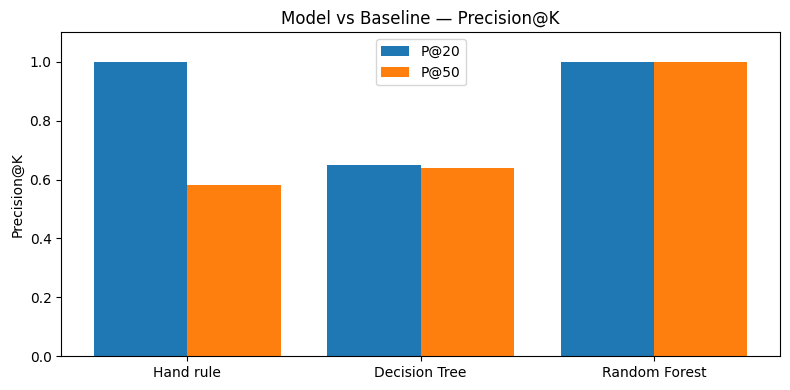

Saved → model_vs_baseline.png


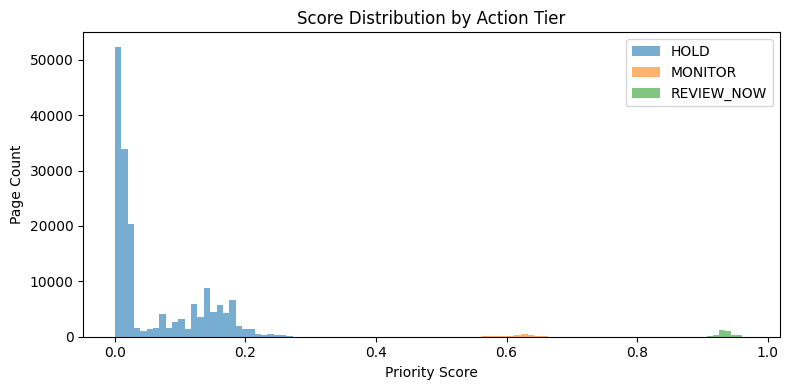

Saved → score_distribution.png


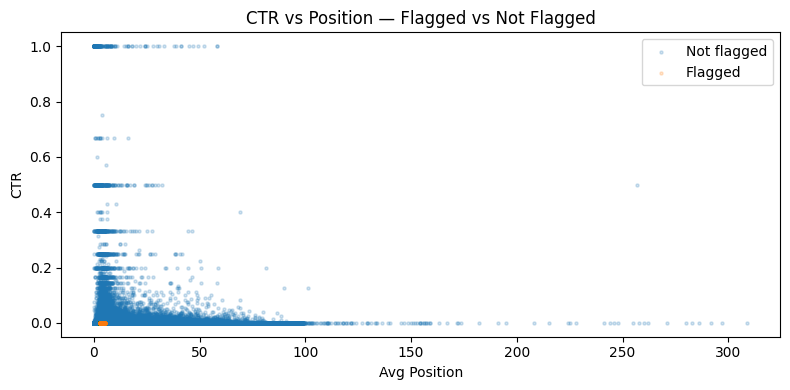

Saved → ctr_vs_position.png

=== All artifacts ready for paper ===
  ✅ work/figures/model_vs_baseline.png
  ✅ work/figures/score_distribution.png
  ✅ work/figures/ctr_vs_position.png


In [20]:
os.makedirs("work/figures", exist_ok=True)
os.makedirs("docs/figures", exist_ok=True)

# Figure 1 — model vs baseline bar chart
fig, ax = plt.subplots(figsize=(8, 4))
methods = ["Hand rule", "Decision Tree", "Random Forest"]
p20s = [metrics["hand_rule"]["p@20"],
        metrics["decision_tree"]["p@20"],
        metrics["random_forest"]["p@20"]]
p50s = [metrics["hand_rule"]["p@50"],
        metrics["decision_tree"]["p@50"],
        metrics["random_forest"]["p@50"]]
x = np.arange(len(methods))
ax.bar(x - 0.2, p20s, 0.4, label="P@20")
ax.bar(x + 0.2, p50s, 0.4, label="P@50")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Precision@K")
ax.set_title("Model vs Baseline — Precision@K")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.savefig("docs/figures/model_vs_baseline.png", dpi=150)
plt.show()
print("Saved → model_vs_baseline.png")

# Figure 2 — score distribution by action tier
fig, ax = plt.subplots(figsize=(8, 4))
for tier, grp in df.groupby("action_tier"):
    ax.hist(grp["priority_score"], bins=30, alpha=0.6, label=tier)
ax.set_xlabel("Priority Score")
ax.set_ylabel("Page Count")
ax.set_title("Score Distribution by Action Tier")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/score_distribution.png", dpi=150)
plt.savefig("docs/figures/score_distribution.png", dpi=150)
plt.show()
print("Saved → score_distribution.png")

# Figure 3 — CTR vs position
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby("is_declining_label"):
    ax.scatter(grp["avg_position"], grp["ctr"],
               alpha=0.2, s=5,
               label="Flagged" if label == 1 else "Not flagged")
ax.set_xlabel("Avg Position")
ax.set_ylabel("CTR")
ax.set_title("CTR vs Position — Flagged vs Not Flagged")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/ctr_vs_position.png", dpi=150)
plt.savefig("docs/figures/ctr_vs_position.png", dpi=150)
plt.show()
print("Saved → ctr_vs_position.png")

print("\n=== All artifacts ready for paper ===")
for f in ["work/figures/model_vs_baseline.png",
          "work/figures/score_distribution.png",
          "work/figures/ctr_vs_position.png"]:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"  {exists} {f}")

In [21]:
from google.colab import files
files.download("work/figures/model_vs_baseline.png")
files.download("work/figures/score_distribution.png")
files.download("work/figures/ctr_vs_position.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
